In [13]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import scipy.interpolate as interpolate

# Funzione gaussiana
def gauss(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Apri il file ROOT
file = uproot.open("/home/riccardo-speziali/after_waveforms_analysis/sampic_mcp_setup_run222_final.root")
tree = file["picoTree"]

# Converti in Awkward Array
data = tree.arrays(library="ak")

# Estrai branch rilevanti
Cell0TimeStamp_PICOSEC = data["Cell0timeSTamp_PICOSEC"]  # array di array
Cell0TimeStamp_MCP    = data["Cell0timestamp_MCP"]       # array piatto
cfd_PICO              = data["pulses_time_cfd30"]       # array di array
cfd_MCP               = data["mcp_time_cfd30"]          # array piatto
hits                  = data["hit_x_event"]             # numero di hit per evento
channel               = data["chanel_PICOSEC"]         # canale PICOSEC
srs                   = data["TriggerIDSRS_MCP"]      # Trigger ID SRS
amplitude_PICOSEC     = data["pulses_amplitude"]     # array di array
e_peak_PICOSEC        = data["pulses_integral"]        # array di array
track_chi_2          = data["track_chi_2"]             # chi2 del track




num_channel = 3

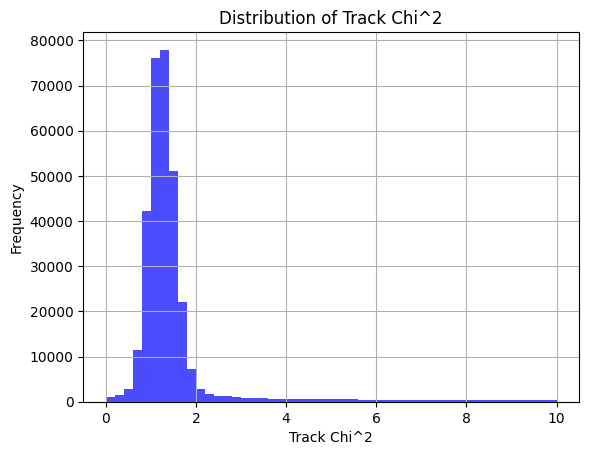

In [14]:
#fit track chi_2
chi_2_values = ak.to_numpy(track_chi_2)
chi_2_values = chi_2_values[~np.isnan(chi_2_values)]
plt.hist(chi_2_values, bins=50, range=(0, 10), alpha=0.7, color='blue')
plt.xlabel('Track Chi^2')
plt.ylabel('Frequency')
plt.title('Distribution of Track Chi^2')
plt.grid()
plt.show()

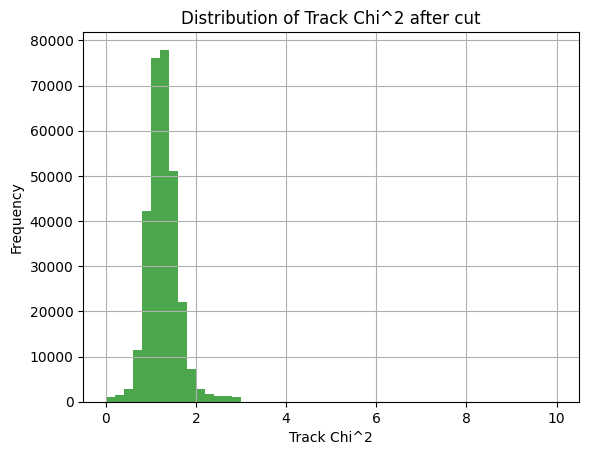

In [15]:
#keep events with good track fit anche per eventi con più di un hit
good_track_mask = chi_2_values < 3
good_tracks = ak.mask(track_chi_2, good_track_mask)
#plot track chi_2 distribution after cut
good_chi_2_values = ak.to_numpy(good_tracks)
good_chi_2_values = good_chi_2_values[~np.isnan(good_chi_2_values)]
plt.hist(good_chi_2_values, bins=50, range=(0, 10), alpha=0.7, color='green')
plt.xlabel('Track Chi^2')
plt.ylabel('Frequency')
plt.title('Distribution of Track Chi^2 after cut')
plt.grid()
plt.show()



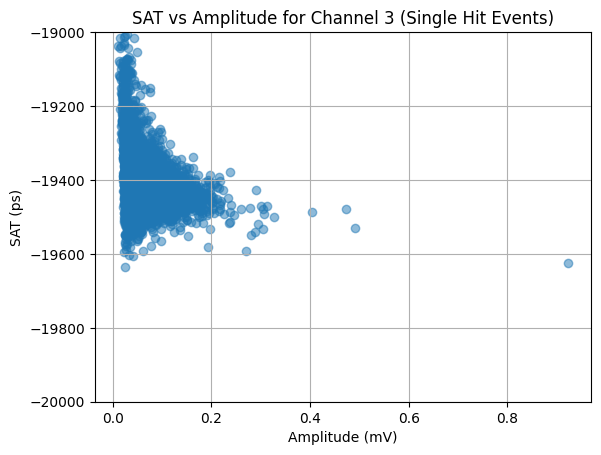

0.9241461753845215


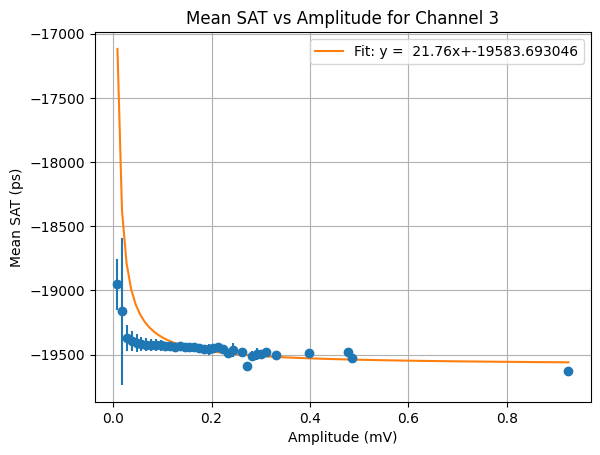

In [16]:
channel_mask = channel[:, 0] == num_channel
single_hit_mask = hits == 1

valid_mask = (
    (ak.num(amplitude_PICOSEC) >= 1) &
    (ak.num(cfd_PICO) >= 1) &
    good_track_mask
)

event_mask = channel_mask & single_hit_mask & valid_mask

good_amplitude = amplitude_PICOSEC[event_mask][:,0]





good_SAT = (cfd_PICO[event_mask][:,0] - cfd_MCP[event_mask] - (Cell0TimeStamp_MCP[event_mask]*1e3-Cell0TimeStamp_PICOSEC[event_mask][:,0]*1e3))





plt.scatter(good_amplitude, good_SAT, alpha=0.5)
plt.xlabel('Amplitude (mV)')
plt.ylabel('SAT (ps)')
plt.title(f'SAT vs Amplitude for Channel {num_channel} (Single Hit Events)')
plt.ylim(-20000,-19000)
plt.grid()
plt.show()



#altro plot dividere il grafico in bin e prendere la media per ogni bin
bins = np.linspace(ak.min(good_amplitude)-1, ak.max(good_amplitude)+1, 300)
bin_indices = np.digitize(good_amplitude, bins)
print(ak.max(good_amplitude))

bin_means = []
bin_std = []
bin_echarge_means = []
bin_echarge_std = []
for i in range(1, len(bins)):
    mask = bin_indices == i
    if ak.sum(mask) > 0:
        bin_means.append(ak.mean(good_SAT[mask]))
        bin_std.append(ak.std(good_SAT[mask]))
        bin_echarge_means.append(ak.mean(e_peak_PICOSEC[event_mask][:,0][mask]))
        bin_echarge_std.append(ak.std(e_peak_PICOSEC[event_mask][:,0][mask]))
    else:
        bin_means.append(np.nan)
        bin_std.append(np.nan)
        bin_echarge_means.append(np.nan)
        bin_echarge_std.append(np.nan)

bin_centers = 0.5 * (bins[:-1] + bins[1:])




# converti in NumPy
bin_means_np = ak.to_numpy(bin_means)
bin_std_np = ak.to_numpy(bin_std)
bin_centers_np = ak.to_numpy(bin_centers)

# filtro valori validi
mask = (~np.isnan(bin_means_np)) & (bin_centers_np > 0)
x = bin_centers_np[mask]
y = bin_means_np[mask]
err = bin_std_np[mask]

# fix valori critici
x = x + 1e-6                # evita log(0)
err = np.where(np.isnan(err) | (err == 0), 1e-6, err)

# funzione logaritmica
def func(x,b,c):
    return   + b/x +c

# fit pesato
#bounds = ([0, -np.inf,-np.inf], [2, np.inf,np.inf])

popt, pcov = curve_fit(func, x, y, sigma=err, absolute_sigma=True)
b, c= popt

# curva fittata
x_fit = np.linspace(min(x), max(x), 100)
y_fit = func(x_fit, b,c)

# plot
plt.errorbar(x, y, err, marker='o', linestyle='none')
plt.plot(x_fit, y_fit, label=f'Fit: y =  {b:.2f}x+{c:2f}')
plt.xlabel('Amplitude (mV)')
plt.ylabel('Mean SAT (ps)')
plt.title(f'Mean SAT vs Amplitude for Channel {num_channel}')
plt.grid()
plt.legend()
plt.show()

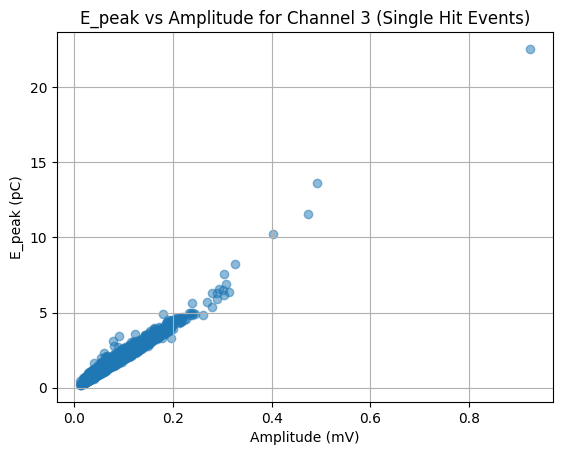

In [17]:
#amplitude vs e_peak
epeak_mask = ak.num(e_peak_PICOSEC) >= 1
valid_epeak_mask = event_mask & epeak_mask
good_epeak = e_peak_PICOSEC[valid_epeak_mask][:,0]

plt.scatter(good_amplitude, good_epeak, alpha=0.5)
plt.xlabel('Amplitude (mV)')
plt.ylabel('E_peak (pC)')
plt.title(f'E_peak vs Amplitude for Channel {num_channel} (Single Hit Events)')
plt.grid()
plt.show()



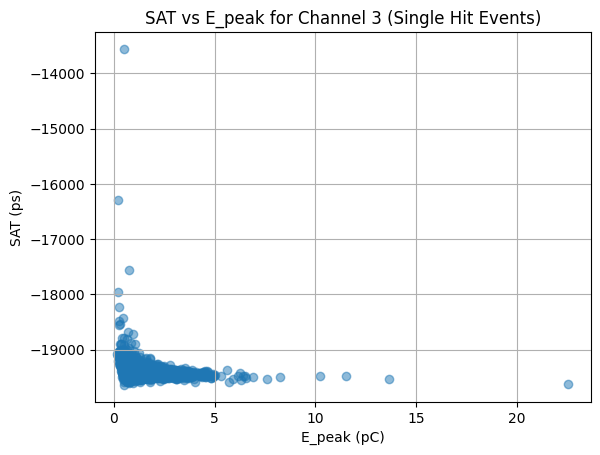

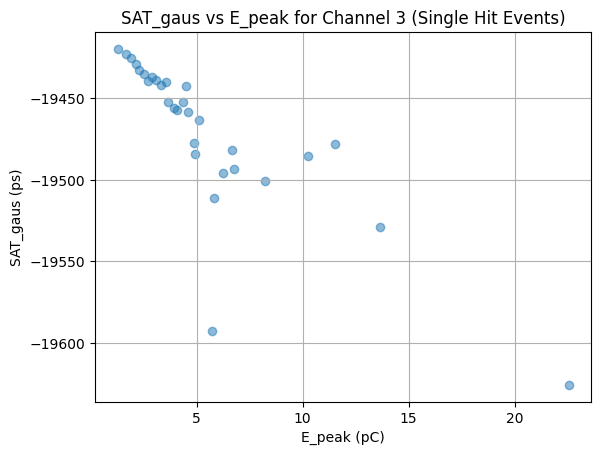

In [18]:
#sat vs charge
plt.scatter( good_epeak, good_SAT, alpha=0.5)
plt.xlabel('E_peak (pC)')
plt.ylabel('SAT (ps)')
plt.title(f'SAT vs E_peak for Channel {num_channel} (Single Hit Events)')
plt.grid()  
plt.show()


#sat_gaus vs charge


plt.scatter(bin_echarge_means, bin_means, alpha=0.5)
plt.xlabel('E_peak (pC)')
plt.ylabel('SAT_gaus (ps)')
plt.title(f'SAT_gaus vs E_peak for Channel {num_channel} (Single Hit Events)')
plt.grid()
plt.show()


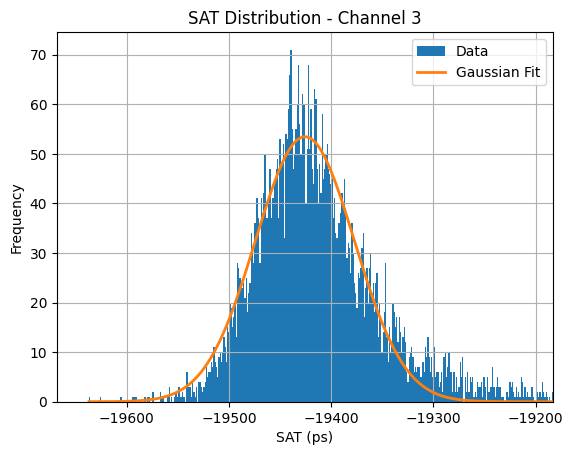

mu = -19425.66 ps, sigma = 48.48 ps


In [19]:
# pulizia dati
sat_values = ak.to_numpy(good_SAT)
sat_values = sat_values[~np.isnan(sat_values)]

mean = np.mean(sat_values)
std = np.std(sat_values)
#sat_values = sat_values[(sat_values > mean - 5*std) & (sat_values < mean + 5*std)]

# bin più ragionevoli
seg = 5000

# istogramma
hist, bin_edges = np.histogram(sat_values, bins=seg)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# fit gaussiano
popt, pcov = curve_fit(
    gauss,
    bin_centers,
    hist,
    p0=[max(hist), mean, std]
)

A_fit, mu_fit, sigma_fit = popt

# curva fit
x_fit = np.linspace(bin_edges[0], bin_edges[-1], 5000)
y_fit = gauss(x_fit, *popt)

# plot
plt.hist(sat_values, bins=seg, alpha=1, label='Data')
plt.plot(x_fit, y_fit, linewidth=2, label='Gaussian Fit')

plt.xlabel('SAT (ps)')
plt.ylabel('Frequency')
plt.title(f'SAT Distribution - Channel {num_channel}')
plt.xlim(mu_fit - 5*sigma_fit, mu_fit + 5*sigma_fit)
plt.legend()
plt.grid()
plt.show()

print(f"mu = {mu_fit:.2f} ps, sigma = {sigma_fit:.2f} ps")

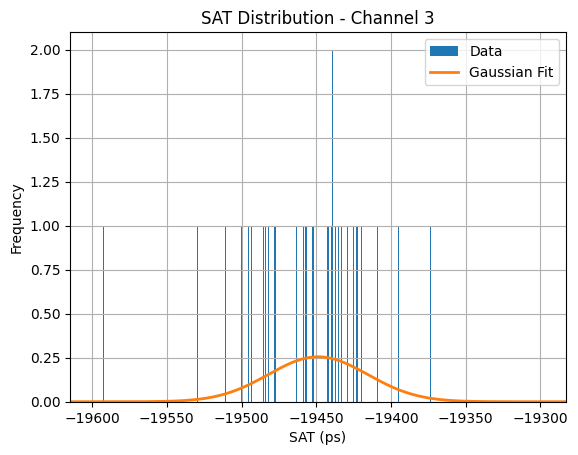

mu = -19448.77 ps, sigma = 33.20 ps


In [20]:
# pulizia dati
#sat_values = ak.to_numpy(good_SAT)
#sat_values = sat_values[~np.isnan(sat_values)]
# rimuovi NaN in modo consistente
mask = ~np.isnan(bin_means_np) & ~np.isnan(bin_std_np)

clean_means = bin_means_np[mask]
clean_std = bin_std_np[mask]

mean = np.mean(clean_means)
std = np.std(clean_std)
#sat_values = sat_values[(sat_values > mean - 5*std) & (sat_values < mean + 5*std)]

# bin più ragionevoli
seg = 1000

# istogramma
hist, bin_edges = np.histogram(clean_means, bins=seg)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# fit gaussiano
popt, pcov = curve_fit(
    gauss,
    bin_centers,
    hist,
    p0=[max(hist), mean, std]
)

A_fit, mu_fit, sigma_fit = popt

# curva fit
x_fit = np.linspace(bin_edges[0], bin_edges[-1], 500)
y_fit = gauss(x_fit, *popt)

# plot
plt.hist(bin_means_np, bins=seg, alpha=1, label='Data')
plt.plot(x_fit, y_fit, linewidth=2, label='Gaussian Fit')

plt.xlabel('SAT (ps)')
plt.ylabel('Frequency')
plt.title(f'SAT Distribution - Channel {num_channel}')
plt.xlim(mu_fit - 5*sigma_fit, mu_fit + 5*sigma_fit)
plt.legend()
plt.grid()
plt.show()

print(f"mu = {mu_fit:.2f} ps, sigma = {sigma_fit:.2f} ps")

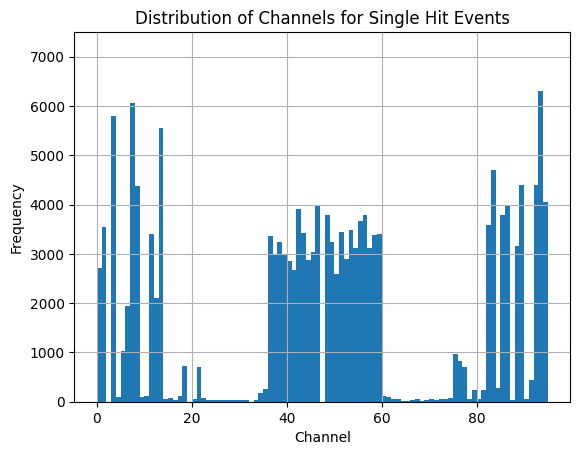

In [21]:
#most hitted channels
mask_here = single_hit_mask & valid_mask & good_track_mask
plt.hist(channel[mask_here][:, 0], bins=np.arange(0, 96, 1), alpha=1)
plt.xlabel('Channel')
plt.ylabel('Frequency')
plt.title('Distribution of Channels for Single Hit Events')
plt.ylim(0, 7500)  # Imposta un limite massimo per l'asse y
plt.grid()
plt.show()

In [22]:
flat_channels = channel[mask_here][:, 0]
flat_channels

<Array [46, 83, 46, 46, 42, 46, ..., 43, 6, 5, 6, 1, 5] type='157791 * int32'>

In [23]:
# funziona che mi ordina i canali piu colpiti indicandomi anche il numero di eventi con 1 hit

#flat_channels = ak.flatten(channel[single_hit_mask])
#channel_counts = np.bincount(flat_channels)
channel_counts = np.bincount(flat_channels)
sorted_indices = np.argsort(channel_counts)[::-1]
sorted_channels = np.arange(96)[sorted_indices]
sorted_counts = channel_counts[sorted_indices]

print("Canali più colpiti (ordinati):")
for ch, count in zip(sorted_channels, sorted_counts):
    print(f"Canale {ch}: {count} eventi")

Canali più colpiti (ordinati):
Canale 93: 6313 eventi
Canale 7: 6070 eventi
Canale 3: 5788 eventi
Canale 13: 5549 eventi
Canale 83: 4701 eventi
Canale 89: 4403 eventi
Canale 92: 4389 eventi
Canale 8: 4385 eventi
Canale 86: 3999 eventi
Canale 46: 3992 eventi
Canale 42: 3905 eventi
Canale 56: 3799 eventi
Canale 85: 3787 eventi
Canale 48: 3783 eventi
Canale 55: 3675 eventi
Canale 82: 3583 eventi
Canale 1: 3539 eventi
Canale 53: 3485 eventi
Canale 51: 3443 eventi
Canale 43: 3433 eventi
Canale 95: 3431 eventi
Canale 11: 3409 eventi
Canale 59: 3399 eventi
Canale 58: 3378 eventi
Canale 36: 3354 eventi
Canale 38: 3246 eventi
Canale 49: 3235 eventi
Canale 88: 3166 eventi
Canale 57: 3125 eventi
Canale 54: 3113 eventi
Canale 45: 3040 eventi
Canale 39: 2985 eventi
Canale 37: 2979 eventi
Canale 52: 2893 eventi
Canale 44: 2882 eventi
Canale 40: 2863 eventi
Canale 0: 2717 eventi
Canale 41: 2671 eventi
Canale 50: 2597 eventi
Canale 12: 2095 eventi
Canale 6: 1935 eventi
Canale 5: 1030 eventi
Canale 75:

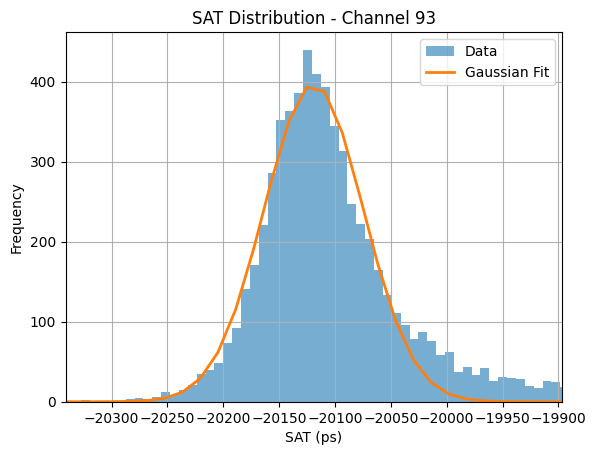

Channel 93: mu = -20119.13 ps, sigma = 44.41 ps


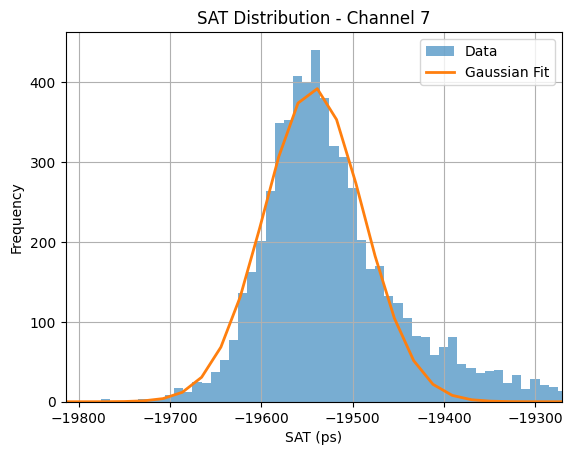

Channel 7: mu = -19542.56 ps, sigma = 54.30 ps


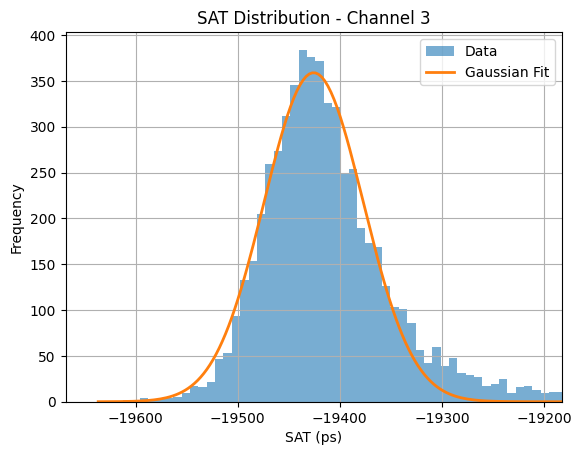

Channel 3: mu = -19425.65 ps, sigma = 48.61 ps


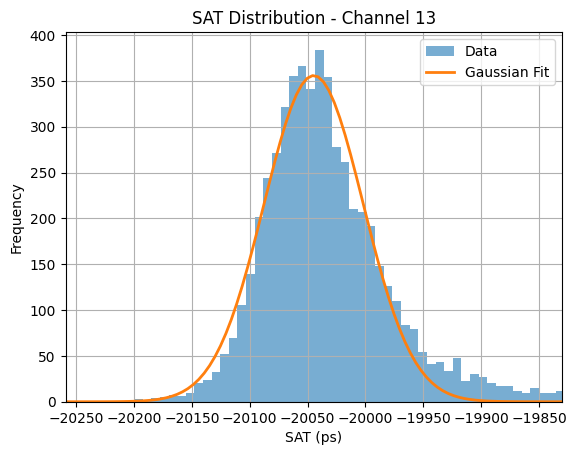

Channel 13: mu = -20044.79 ps, sigma = 42.87 ps


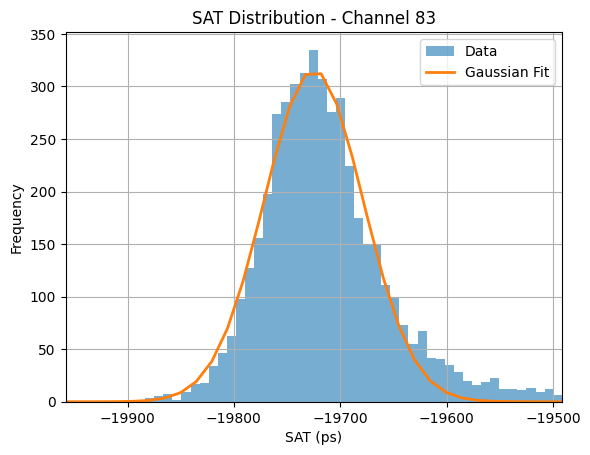

Channel 83: mu = -19724.99 ps, sigma = 46.64 ps


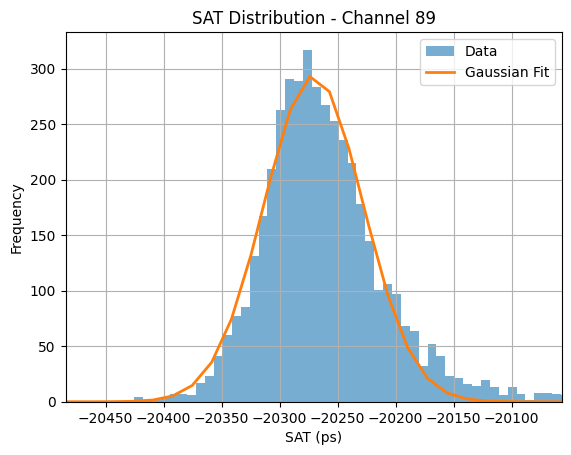

Channel 89: mu = -20270.70 ps, sigma = 42.75 ps


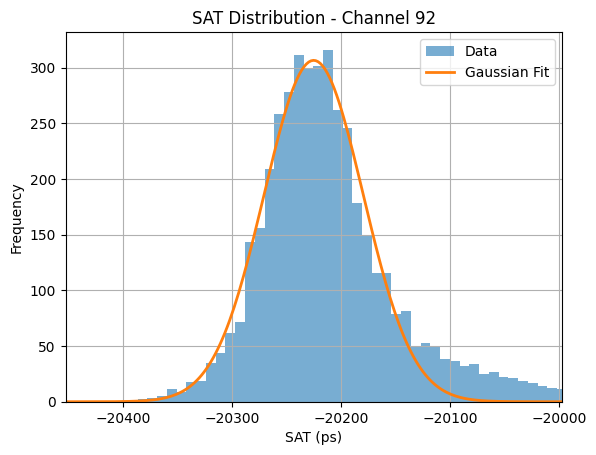

Channel 92: mu = -20225.18 ps, sigma = 45.54 ps


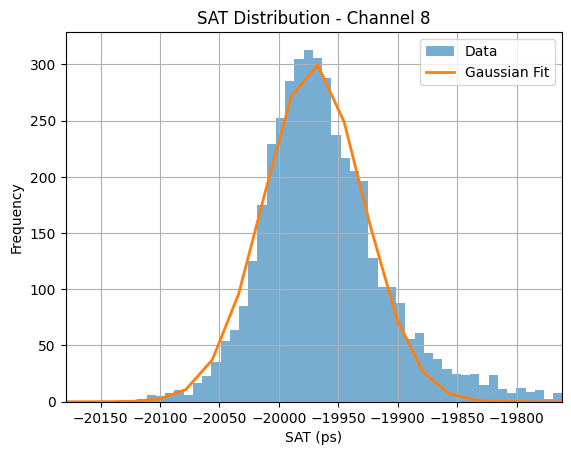

Channel 8: mu = -19970.81 ps, sigma = 41.71 ps


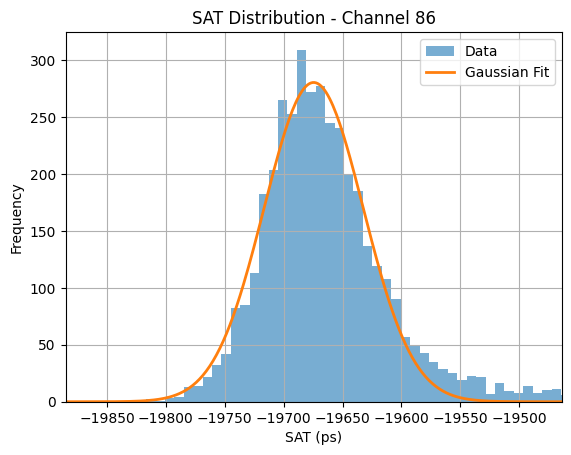

Channel 86: mu = -19674.52 ps, sigma = 42.10 ps


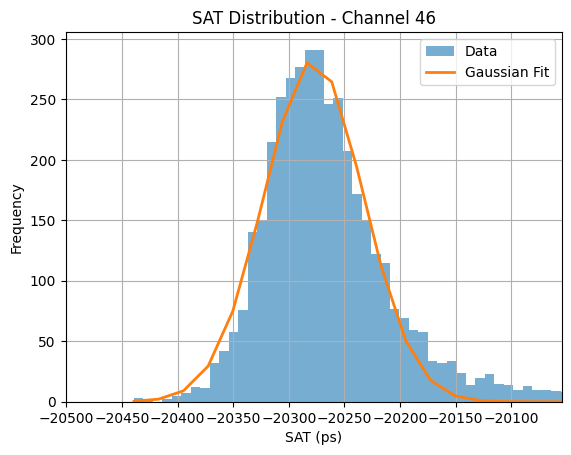

Channel 46: mu = -20277.68 ps, sigma = 44.62 ps


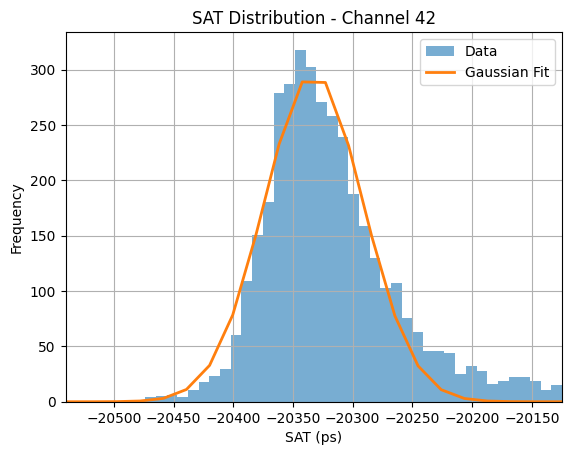

Channel 42: mu = -20332.65 ps, sigma = 41.53 ps


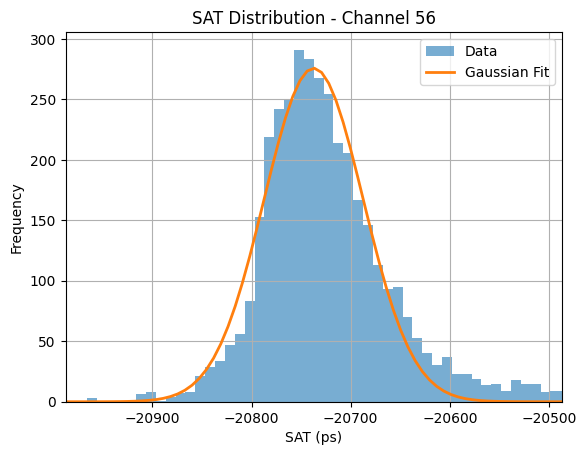

Channel 56: mu = -20737.33 ps, sigma = 50.03 ps


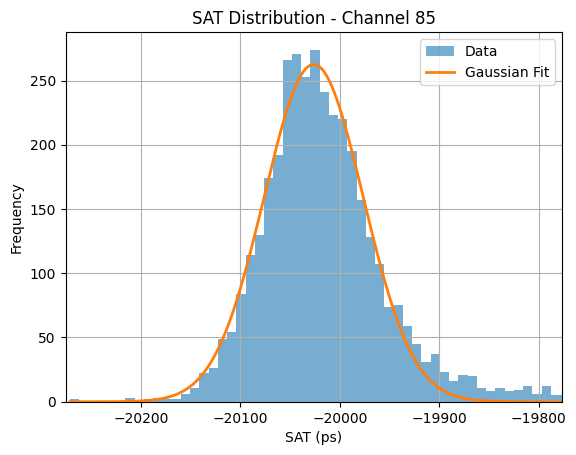

Channel 85: mu = -20026.36 ps, sigma = 49.89 ps


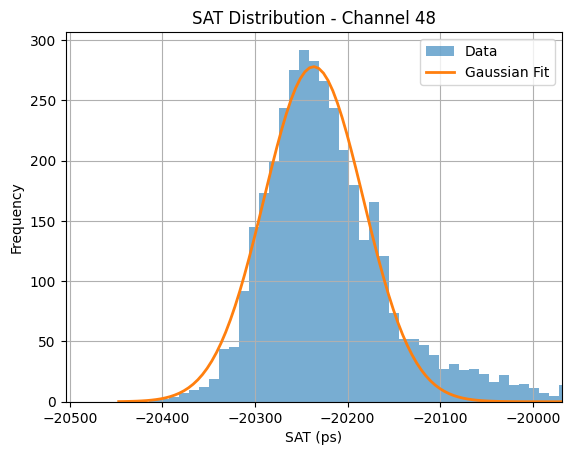

Channel 48: mu = -20236.75 ps, sigma = 53.56 ps


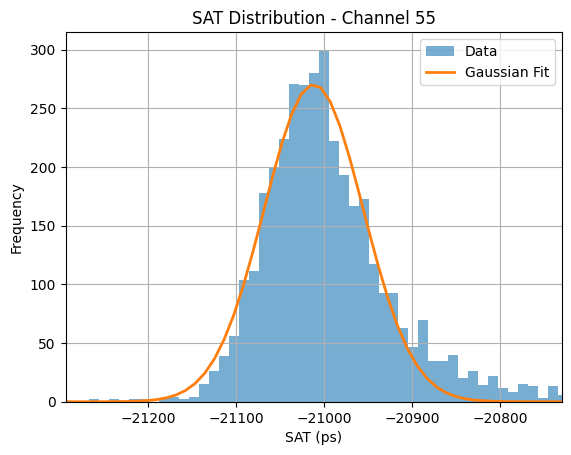

Channel 55: mu = -21011.93 ps, sigma = 56.34 ps


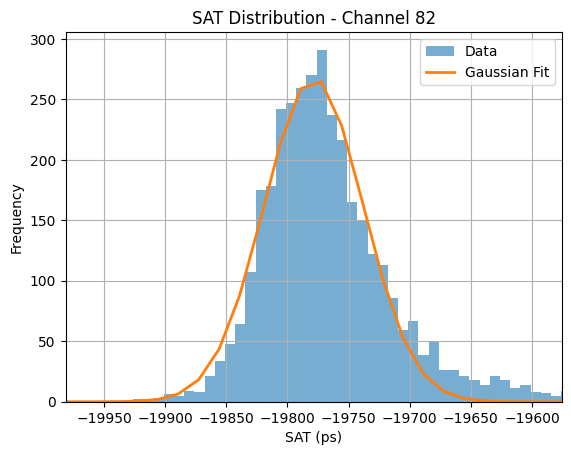

Channel 82: mu = -19778.53 ps, sigma = 40.56 ps


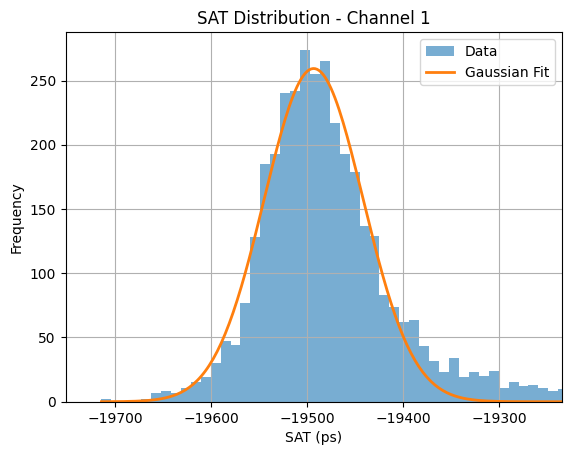

Channel 1: mu = -19493.41 ps, sigma = 51.68 ps


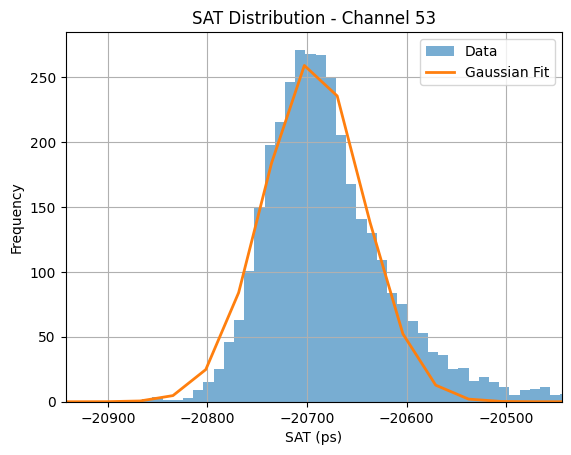

Channel 53: mu = -20693.33 ps, sigma = 49.84 ps


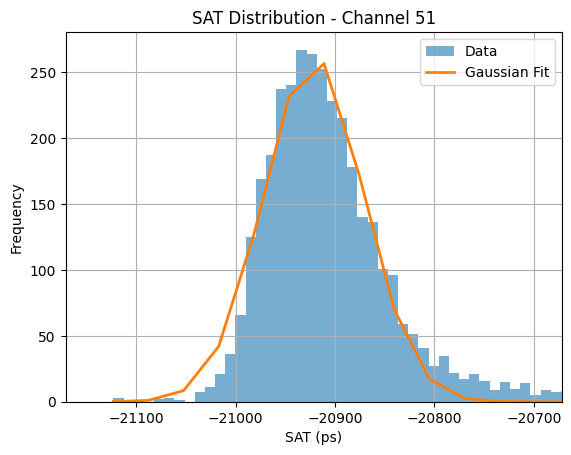

Channel 51: mu = -20921.54 ps, sigma = 49.93 ps


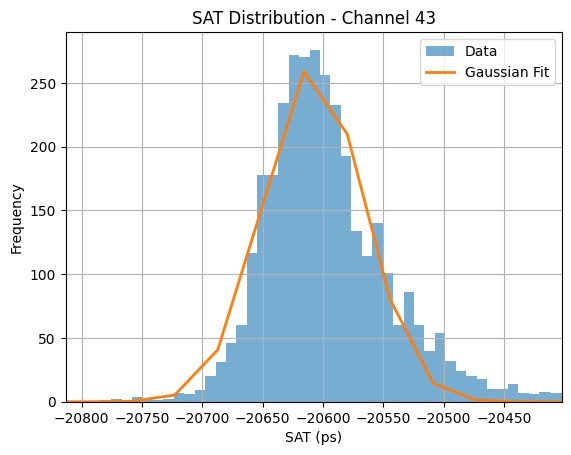

Channel 43: mu = -20607.70 ps, sigma = 41.13 ps


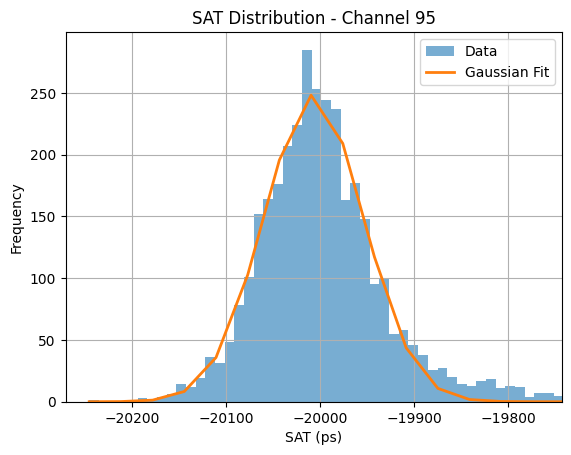

Channel 95: mu = -20007.08 ps, sigma = 52.76 ps


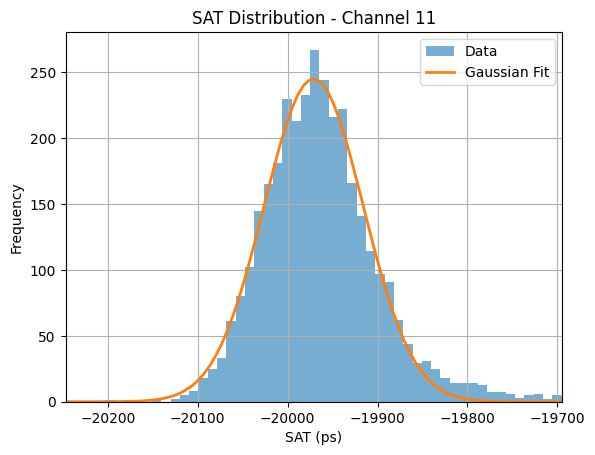

Channel 11: mu = -19971.09 ps, sigma = 55.16 ps


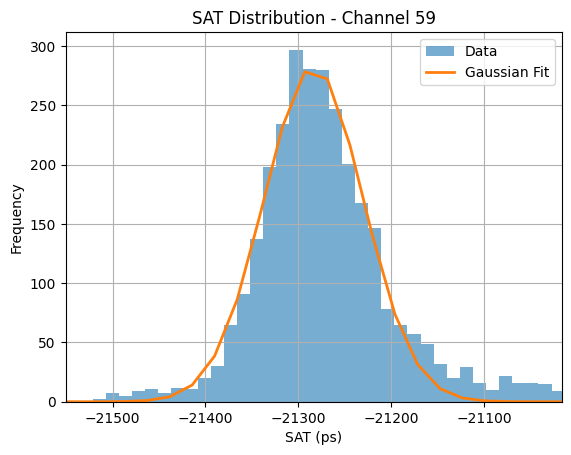

Channel 59: mu = -21283.55 ps, sigma = 53.40 ps


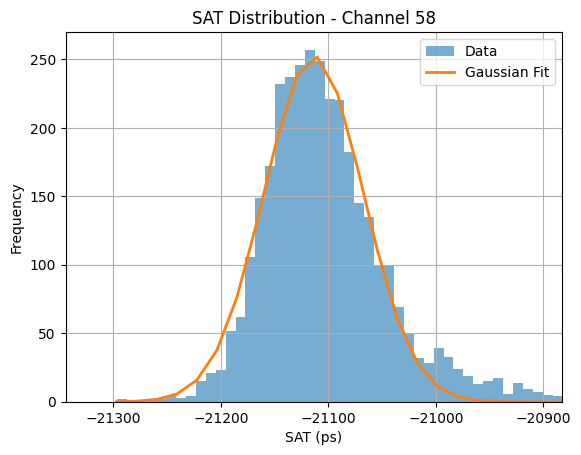

Channel 58: mu = -21113.72 ps, sigma = 46.16 ps


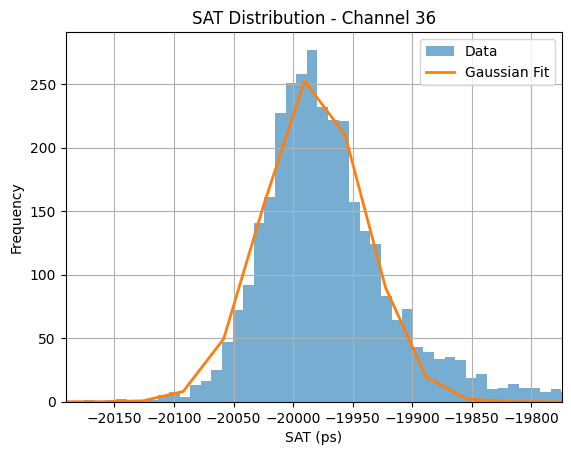

Channel 36: mu = -19982.68 ps, sigma = 41.66 ps


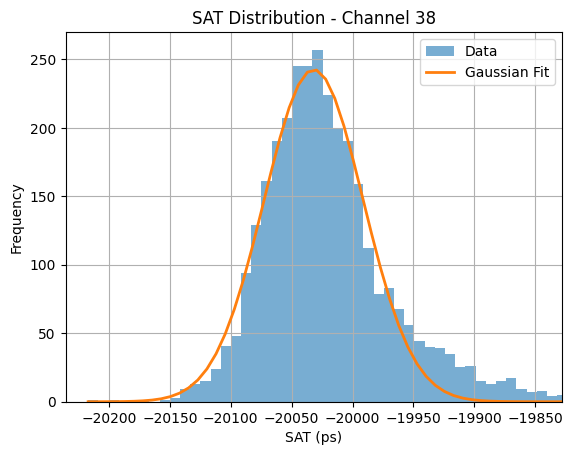

Channel 38: mu = -20031.94 ps, sigma = 40.72 ps


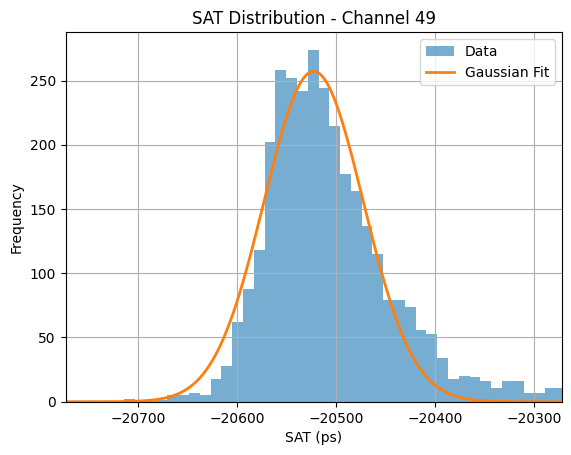

Channel 49: mu = -20522.71 ps, sigma = 50.08 ps


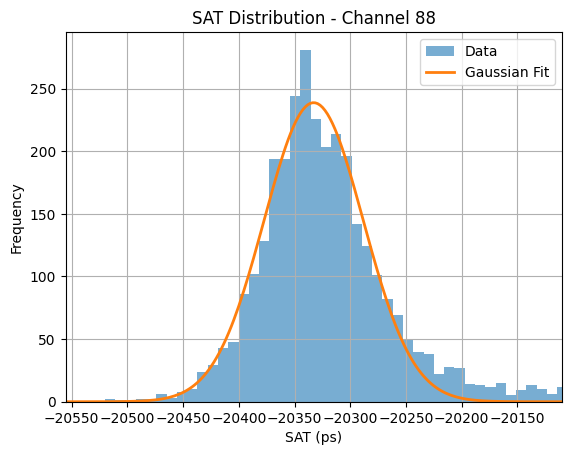

Channel 88: mu = -20332.85 ps, sigma = 44.52 ps


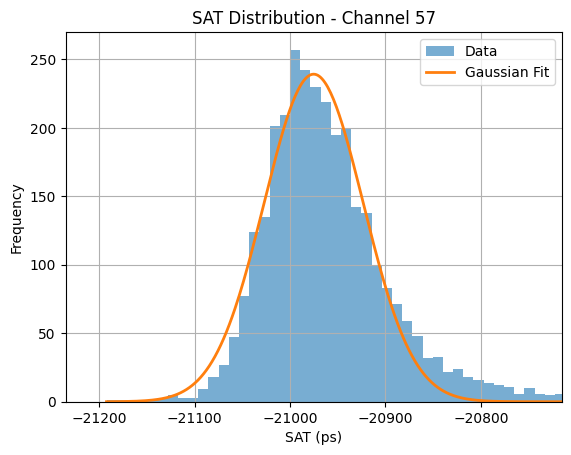

Channel 57: mu = -20975.25 ps, sigma = 51.99 ps


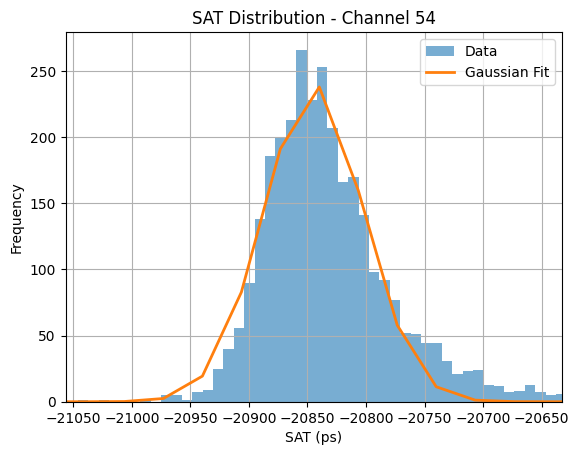

Channel 54: mu = -20844.74 ps, sigma = 42.38 ps


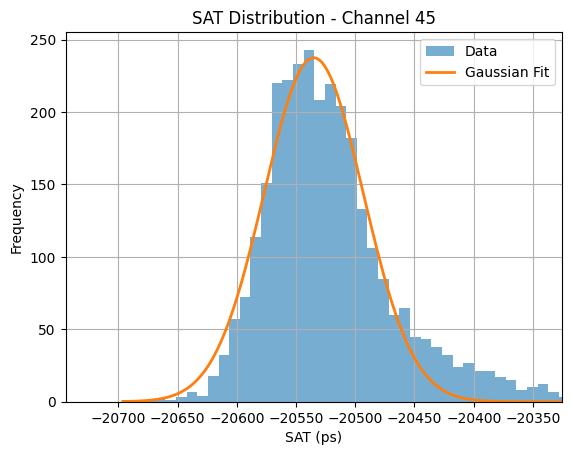

Channel 45: mu = -20535.12 ps, sigma = 41.87 ps


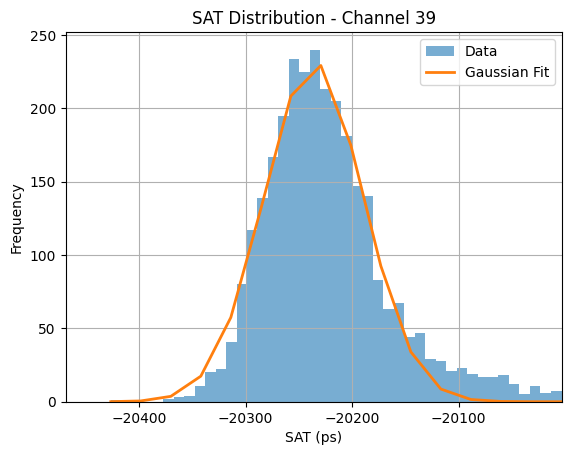

Channel 39: mu = -20236.14 ps, sigma = 46.61 ps


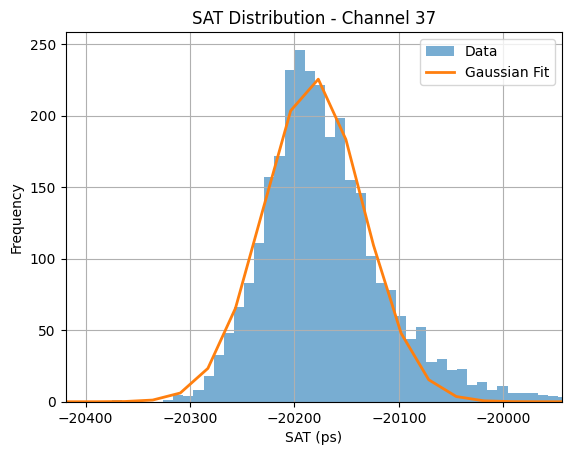

Channel 37: mu = -20181.55 ps, sigma = 47.51 ps


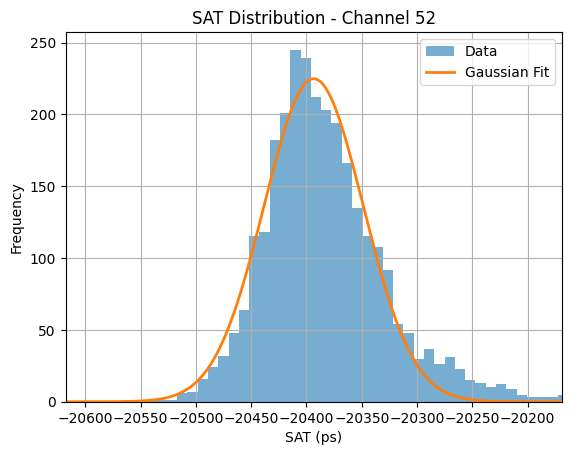

Channel 52: mu = -20393.49 ps, sigma = 44.87 ps


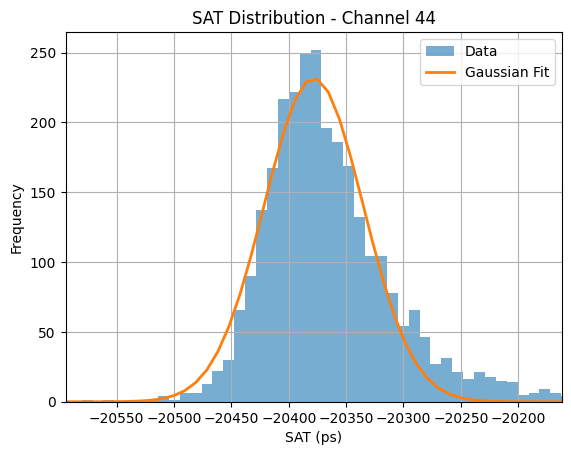

Channel 44: mu = -20378.28 ps, sigma = 43.23 ps


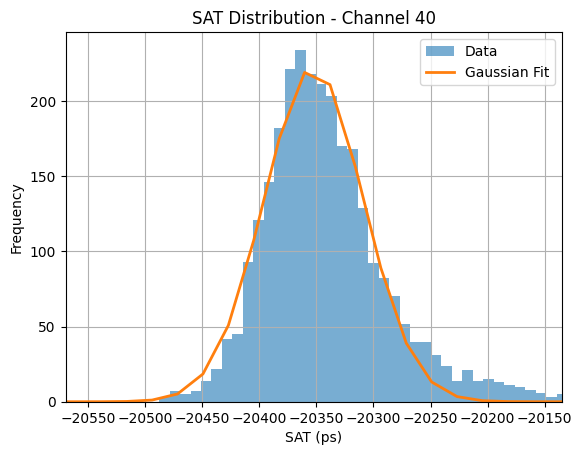

Channel 40: mu = -20352.42 ps, sigma = 43.46 ps


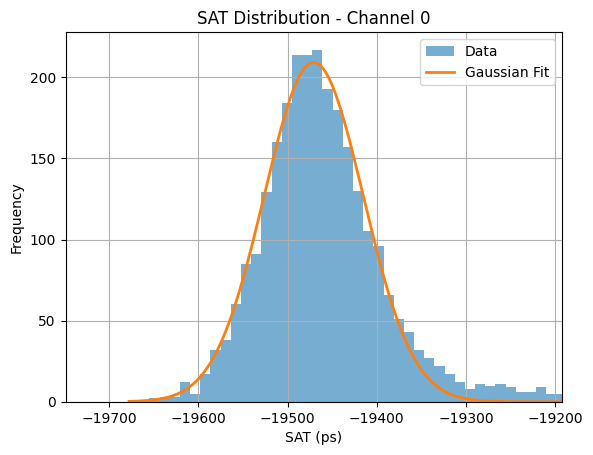

Channel 0: mu = -19470.76 ps, sigma = 55.55 ps


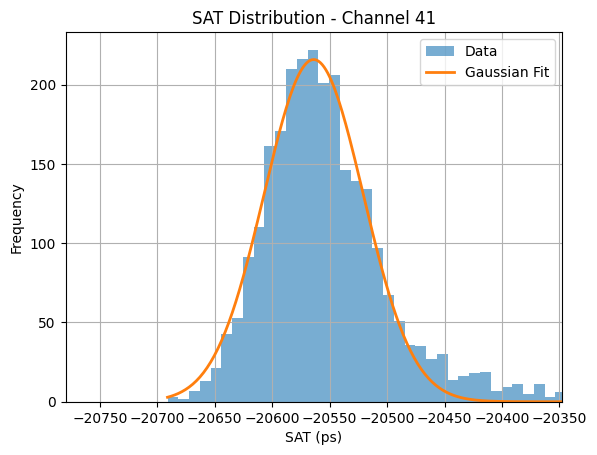

Channel 41: mu = -20563.92 ps, sigma = 43.17 ps


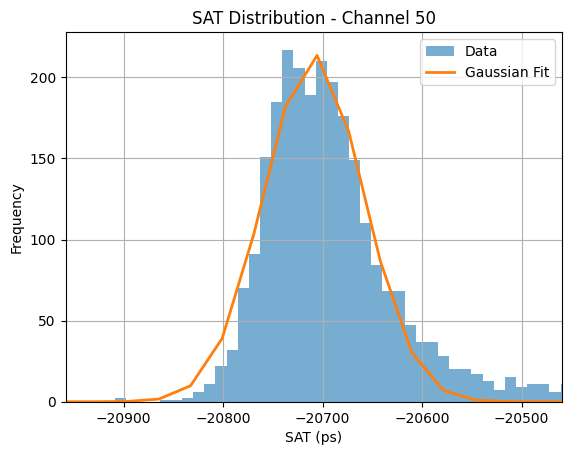

Channel 50: mu = -20708.98 ps, sigma = 49.85 ps


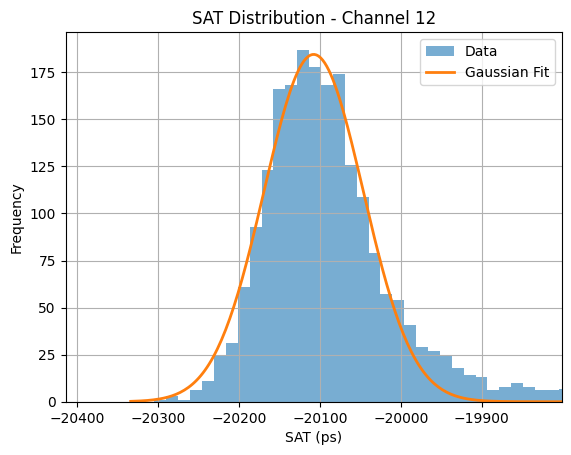

Channel 12: mu = -20107.78 ps, sigma = 61.35 ps


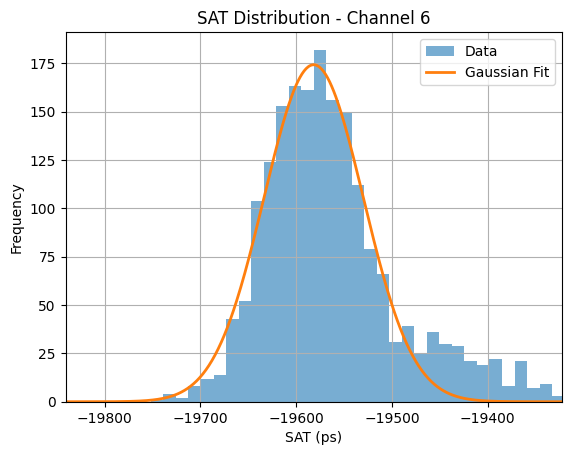

Channel 6: mu = -19581.73 ps, sigma = 51.78 ps


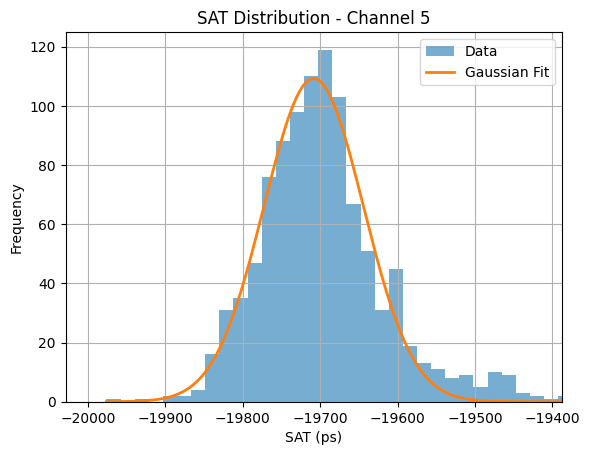

Channel 5: mu = -19708.39 ps, sigma = 64.05 ps


In [24]:
##### analisi di tutti i canali con almeno 1000 eventi
sorted_sigmas = []
sorted_channels_ok= []
for x in sorted_channels:
    ##gaus analysis
    channel_mask = channel[:, 0] == x
    single_hit_mask = hits == 1
    valid_mask = (
        (ak.num(amplitude_PICOSEC) >= 1) &
        (ak.num(cfd_PICO) >= 1) &
        good_track_mask
    )
    event_mask = channel_mask & single_hit_mask & valid_mask
    good_amplitude = amplitude_PICOSEC[event_mask][:,0]
    good_SAT = cfd_PICO[event_mask][:,0] - cfd_MCP[event_mask] - (Cell0TimeStamp_MCP[event_mask]*1e3-Cell0TimeStamp_PICOSEC[event_mask][:,0]*1e3)   
    sat_values = ak.to_numpy(good_SAT)
    sat_values = sat_values[~np.isnan(sat_values)]
    if len(sat_values) < 1000:
        continue
    mean = np.mean(sat_values)
    std = np.std(sat_values)
    bins = 'fd'
    hist, bin_edges = np.histogram(sat_values, bins=bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    popt, pcov = curve_fit(
    gauss,
    bin_centers,
    hist,
    p0=[max(hist), mean, std],
    bounds=([0, -np.inf, 0], [np.inf, np.inf, np.inf])
)
    A_fit, mu_fit, sigma_fit = popt
    x_fit = np.linspace(bin_edges[0], bin_edges[-1], 2000)
    y_fit = gauss(x_fit, *popt)
    plt.hist(sat_values, bins=bins, alpha=0.6, label='Data')
    plt.plot(x_fit, y_fit, linewidth=2, label='Gaussian Fit')
    plt.xlabel('SAT (ps)')
    plt.ylabel('Frequency')
    plt.title(f'SAT Distribution - Channel {x}')
    plt.xlim(mu_fit - 5*sigma_fit, mu_fit + 5*sigma_fit)
    plt.legend()
    plt.grid()
    plt.show()
    print(f"Channel {x}: mu = {mu_fit:.2f} ps, sigma = {sigma_fit:.2f} ps") 
    sorted_sigmas.append((x, sigma_fit))
    



In [ ]:
#read the position from a txt file of the coordinate of the channels and create a map


